In [1]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI
from pydantic import BaseModel,Field

load_dotenv()

llm=ChatOpenAI(model="deepseek-chat",
               base_url=os.getenv("DEEPSEEK_BASE_URL"),
               api_key=os.getenv("DEEPSEEK_API_KEY"),
               temperature=0)

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph,START,END,MessagesState
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display,Image
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
import json,requests
from langchain_core.messages import AnyMessage, SystemMessage,HumanMessage,AIMessage
from pydantic import BaseModel,Field

memory=MemorySaver()

class WeatherLoc(BaseModel):
    """the location to get the weather"""
    location:str=Field(description="the location to get the weather")

class SearchQuery(BaseModel):
    """the query to fetch real time infor"""
    query:str=Field(description="the query to fetch real time infor")
    
@tool(args_schema=SearchQuery)
def fetch_real_time_info(query):
    """fetch real time info from internet"""
    print("--------------")
    url="https://api.open-meteo.com/v1/forecast?latitude=52.52&longitude=13.41&t_weather=true"
    response=requests.get(url)
    result=json.loads(response.text)
    return result



@tool(args_schema=WeatherLoc)
def get_weather(location):
    """
    
    从 OpenWeather API 实时查询天气。仅在数据库中查询不到该城市天气时使用。
    优先使用 query_weather_from_db 工具。
    
    Function to query content weather.
    "param location: Required parameter, of type string, representing the specific city name for the weather query.
    Note that for cities in China, the corresponding English city name should be used. For example, to query the weather for Beijing,
    the location parameter should be input as 'Beijing'.
    :return: The result of the OpenWeather API query for current weather, with the specific URL request address being: https://api.openweathermap.org/data/2.5/weather.
    The return type is a JSON-formated object after parsing, represented as a string, containing all important weather information.
    
    """
    # step 1 构建请求
    url=os.getenv("WEATHER_API_URL")
    # step 2 设置查询参数
    params={
        "q":location,
        "appid":os.getenv("WEATHER_API_KEY"),
        "units":"metric",
        "lang":"zh_cn"
    }
    response=requests.get(url,params=params)
    data=response.json()
    return json.dumps(data)



In [3]:
tools=[get_weather,fetch_real_time_info]
tool_node=ToolNode(tools)

In [4]:
llm=llm.bind_tools(tools)

In [5]:
from typing import Annotated, Any

from langgraph.graph import add_messages


def should_continue(state):
    if state['messages'][-1].tool_calls:
        return 'function_call'
    else:
        return 'end'
    
def function_call(state):
    result=tool_node.invoke({"messages":[state['messages'][-1]]})
    return result
    
def call_model(state):
    messages=state['messages']
    result=llm.invoke(messages)
    return {"messages":[result]}

class AgentState(TypedDict):
    messages:Annotated[list[Any],add_messages]

builder=StateGraph(AgentState)

builder.add_node('call_model',call_model)
builder.add_node('function_call',function_call)

builder.add_edge(START,'call_model')
builder.add_conditional_edges('call_model',should_continue,{
    'function_call':'function_call',
    'end':END
})

builder.add_edge('function_call','call_model')
builder.add_edge('call_model',END)

graph=builder.compile(checkpointer=memory,interrupt_before=['function_call'])


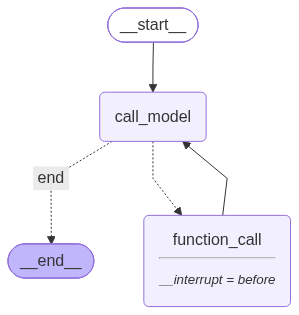

In [6]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
config={'configurable':{'thread_id':'1'}}

async for chunk in graph.astream({'messages':['你好，介绍一下你自己']},config=config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='你好，介绍一下你自己', additional_kwargs={}, response_metadata={}, id='7bff9163-58d0-493f-b2c5-6986574b681c')]}
{'messages': [HumanMessage(content='你好，介绍一下你自己', additional_kwargs={}, response_metadata={}, id='7bff9163-58d0-493f-b2c5-6986574b681c'), AIMessage(content='你好！我是你的智能助手，可以帮你完成各种任务。我具备以下能力：\n\n1. **天气查询**：我可以实时查询全球各城市的天气情况，包括温度、湿度、风力等信息。\n\n2. **实时信息获取**：我可以从互联网上获取最新的实时信息，比如新闻、事件、数据等。\n\n3. **知识问答**：我可以回答各种问题，提供知识性的帮助。\n\n4. **任务执行**：我可以帮你处理各种日常任务，比如查询信息、分析数据等。\n\n无论你是想了解天气、查找资料，还是需要其他帮助，都可以随时告诉我！有什么我可以帮你的吗？😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 132, 'prompt_tokens': 508, 'total_tokens': 640, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 384}, 'prompt_cache_hit_tokens': 384, 'prompt_cache_miss_tokens': 124}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e', 'id': '6efe7ee2

In [10]:
snapshot=graph.get_state(config)
snapshot

StateSnapshot(values={'messages': [HumanMessage(content='你好，介绍一下你自己', additional_kwargs={}, response_metadata={}, id='7bff9163-58d0-493f-b2c5-6986574b681c'), AIMessage(content='你好！我是你的智能助手，可以帮你完成各种任务。我具备以下能力：\n\n1. **天气查询**：我可以实时查询全球各城市的天气情况，包括温度、湿度、风力等信息。\n\n2. **实时信息获取**：我可以从互联网上获取最新的实时信息，比如新闻、事件、数据等。\n\n3. **知识问答**：我可以回答各种问题，提供知识性的帮助。\n\n4. **任务执行**：我可以帮你处理各种日常任务，比如查询信息、分析数据等。\n\n无论你是想了解天气、查找资料，还是需要其他帮助，都可以随时告诉我！有什么我可以帮你的吗？😊', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 132, 'prompt_tokens': 508, 'total_tokens': 640, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 384}, 'prompt_cache_hit_tokens': 384, 'prompt_cache_miss_tokens': 124}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e', 'id': '6efe7ee2-5ad3-43fe-9ddb-4dce1626303b', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a04231-6d75-7f22-b797-6f7d8c

In [7]:
config={'configurable':{'thread_id':'1'}}

async for chunk in graph.astream({'messages':['你好，查询一下北京的天气']},config=config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='你好，查询一下北京的天气', additional_kwargs={}, response_metadata={}, id='0d737603-f7a8-4578-8a10-59870f5985bd')]}
{'messages': [HumanMessage(content='你好，查询一下北京的天气', additional_kwargs={}, response_metadata={}, id='0d737603-f7a8-4578-8a10-59870f5985bd'), AIMessage(content='我来帮你查询北京的天气。让我先尝试从数据库中查询，如果查不到再使用实时天气接口。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 510, 'total_tokens': 576, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 384}, 'prompt_cache_hit_tokens': 384, 'prompt_cache_miss_tokens': 126}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e', 'id': 'ca5423bd-5ce3-42fb-a335-620c60433b45', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a04235-3636-7420-95e5-60c35fc57e6a-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Beijing'}, 'id': 'c

In [8]:
async for chunk in graph.astream(None,config=config,stream_mode="values"):
    chunk['messages'][-1].pretty_print()

================================== Ai Message ==================================

我来帮你查询北京的天气。让我先尝试从数据库中查询，如果查不到再使用实时天气接口。
Tool Calls:
  get_weather (call_00_dfaOLV2aSDvZpZ1Xk0Kg4716)
 Call ID: call_00_dfaOLV2aSDvZpZ1Xk0Kg4716
  Args:
    location: Beijing
================================= Tool Message =================================
Name: get_weather

{"coord": {"lon": 116.3972, "lat": 39.9075}, "weather": [{"id": 804, "main": "Clouds", "description": "\u9634\uff0c\u591a\u4e91", "icon": "04d"}], "base": "stations", "main": {"temp": 27.94, "feels_like": 28.94, "temp_min": 27.94, "temp_max": 27.94, "pressure": 1009, "humidity": 56, "sea_level": 1009, "grnd_level": 1004}, "visibility": 10000, "wind": {"speed": 0.59, "deg": 245, "gust": 1.6}, "clouds": {"all": 100}, "dt": 1787816630, "sys": {"type": 1, "id": 9609, "country": "CN", "sunrise": 1787780233, "sunset": 1787828124}, "timezone": 28800, "id": 1816670, "name": "Beijing", "cod": 200}
================================== Ai Message =